# Final Project - Hospital Readmission

### Goal:
- This machine learning system predicts whether a patient will be readmitted to the hospital within
30 days after discharge. The model is built as a binary classifier using structured patient records
from the Diabetes 130-US hospitals dataset. The goal is to assist hospitals in identifying high-
risk patients so they can intervene early and reduce costly, preventable readmissions

### Data Source:
- Diabetes 130-US hospitals dataset from the UCI Machine Learning Repository


## 01 - Data Loading and SageMaker Feature Store Ingestion

This notebook performs the initial data loading, basic cleaning, and ingestion into SageMaker Feature Store.

It covers:
- Loading raw data (CSV or pickle)
- Preprocessing: dropping unused columns, renaming fields
- Creating a Feature Group in SageMaker
- Ingesting records into both the **online** and **offline** stores
- Saving a cleaned version of the dataset for future steps


In [16]:
# Pip install libraries

!pip install --disable-pip-version-check -q awscli boto3
!pip install --disable-pip-version-check -q sagemaker
!pip install --disable-pip-version-check -q smdebug
!pip install --disable-pip-version-check -q sagemaker-experiments
!pip install --disable-pip-version-check -q PyAthena
!pip install --disable-pip-version-check -q awswrangler
!pip install --disable-pip-version-check -q matplotlib
!pip install --disable-pip-version-check -q seaborn

In [11]:
# Install latest SageMaker SDK

import pandas as pd
import numpy as np
import boto3
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.session import Session
import time
import os
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import seaborn as sns



## Data Loading

In [12]:
# Data loading
data = pd.read_csv('data/diabetic_data.csv')
id_map = pd.read_csv('data/IDS_mapping.csv')

# See data head
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## EDA

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   RecordID                  101766 non-null  int64 
 1   encounter_id              101766 non-null  int64 
 2   patient_nbr               101766 non-null  int64 
 3   race                      101766 non-null  object
 4   gender                    101766 non-null  object
 5   age                       101766 non-null  object
 6   weight                    101766 non-null  object
 7   admission_type_id         101766 non-null  int64 
 8   discharge_disposition_id  101766 non-null  int64 
 9   admission_source_id       101766 non-null  int64 
 10  time_in_hospital          101766 non-null  int64 
 11  payer_code                101766 non-null  object
 12  medical_specialty         101766 non-null  object
 13  num_lab_procedures        101766 non-null  int64 
 14  num_

In [50]:
# Check for null data 

data.isnull().sum()

RecordID                        0
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [51]:
# Check for duplicated data

data.duplicated().sum()

0

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, ' Physician Referral'),
  Text(1, 0, 'HMO Referral'),
  Text(2, 0, 'Clinic Referral'),
  Text(3, 0, ' Transfer from another health care facility'),
  Text(4, 0, ' Transfer from a Skilled Nursing Facility (SNF)'),
  Text(5, 0, ' Court/Law Enforcement'),
  Text(6, 0, ' Emergency Room'),
  Text(7, 0, 'Transfer from a hospital')])

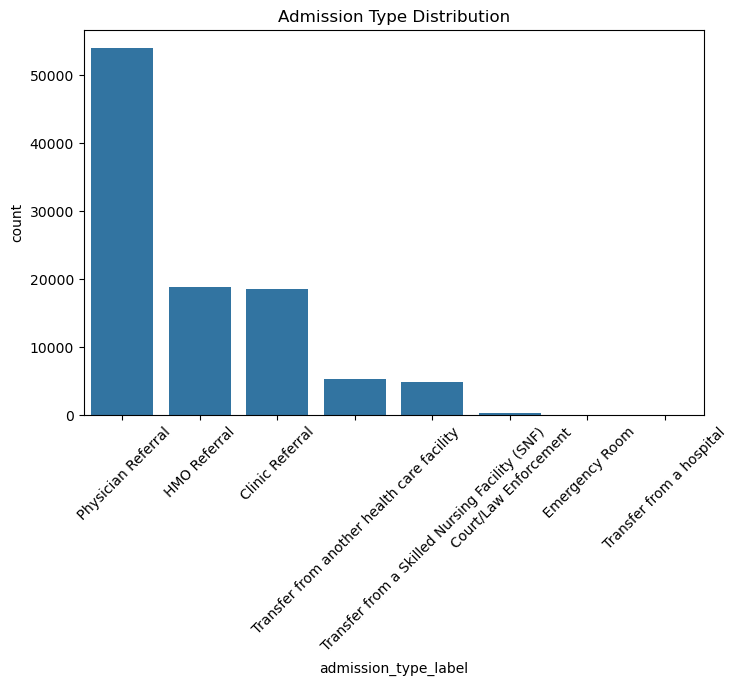

In [57]:
# Readmission classes

plt.figure(figsize=(8, 5))
sns.countplot(x='admission_type_label', data=data, order=data['admission_type_label'].value_counts().index)
plt.title("Admission Type Distribution")
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Number of Inpatient Visits')

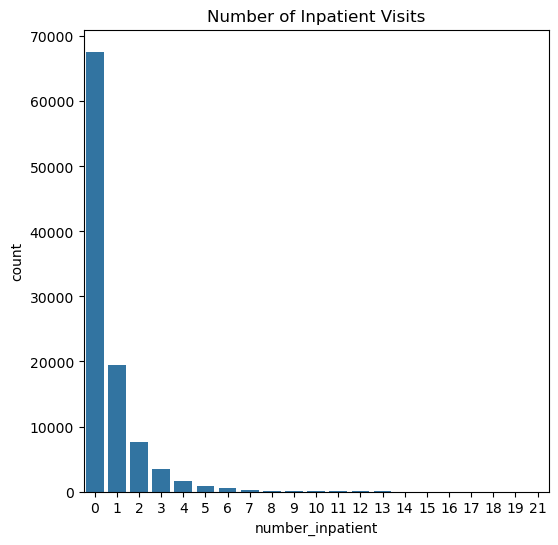

In [58]:
# Inpatient Visits

plt.figure(figsize=(6, 6))
sns.countplot(x='number_inpatient', data=data)
plt.title("Number of Inpatient Visits")


Text(0.5, 1.0, 'Age Distribution of Patients')

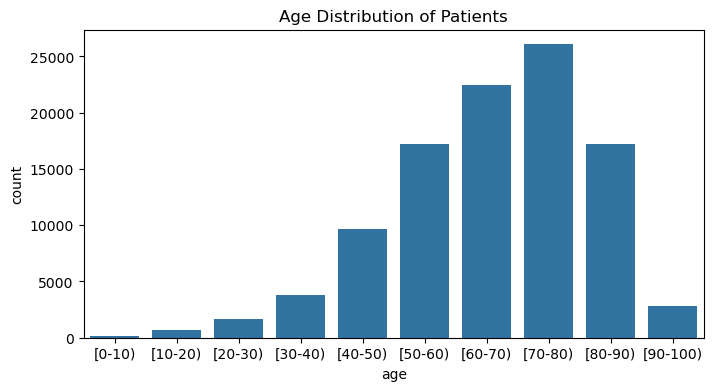

In [59]:
# Age distribution

plt.figure(figsize=(8, 4))
sns.countplot(x='age', data=data, order=sorted(data['age'].unique()))
plt.title("Age Distribution of Patients")


Text(0.5, 1.0, 'Top Admission Types')

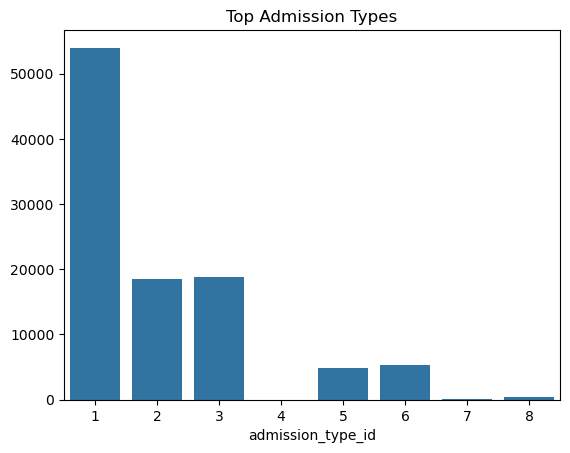

In [60]:
# Admission Types

top_admissions = data['admission_type_id'].value_counts().head(10)
sns.barplot(x=top_admissions.index, y=top_admissions.values)
plt.title("Top Admission Types")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Caucasian'),
  Text(1, 0, 'AfricanAmerican'),
  Text(2, 0, '?'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'Asian'),
  Text(5, 0, 'Hispanic')])

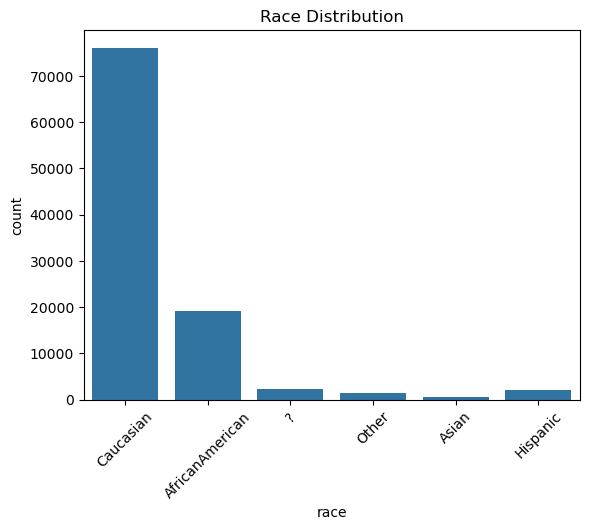

In [61]:
# Race and Ethnicity

sns.countplot(x='race', data=data)
plt.title("Race Distribution")
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Top 10 Discharge Dispositions')

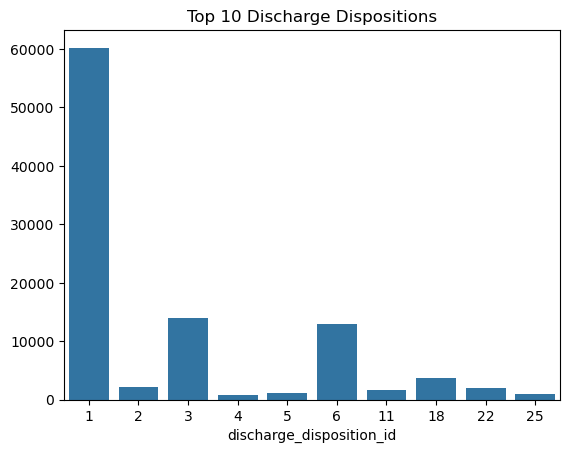

In [62]:
# Discharge disposition

# (See IDS_Mapping.csv for code)

top_dispositions = data['discharge_disposition_id'].value_counts().head(10)
sns.barplot(x=top_dispositions.index, y=top_dispositions.values)
plt.title("Top 10 Discharge Dispositions")


## Preprocess for Feature Store

In [13]:
# Map admission_type_id to description
id_map['admission_type_id'] = pd.to_numeric(id_map['admission_type_id'], errors='coerce')
admission_map_df = id_map.dropna(subset=['admission_type_id'])
admission_map_df = admission_map_df[admission_map_df['admission_type_id'] <= 8]
admission_map = dict(zip(admission_map_df['admission_type_id'].astype(int), admission_map_df['description']))
data['admission_type_label'] = data['admission_type_id'].map(admission_map)

# Add required columns for Feature Store
data.reset_index(inplace=True)
data.rename(columns={'index': 'RecordID'}, inplace=True)
data['EventTime'] = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')

# Sanity check
data[['RecordID', 'admission_type_id', 'admission_type_label', 'EventTime']].head()


,RecordID,admission_type_id,admission_type_label,EventTime
0,0,6,Transfer from another health care facility,2025-06-20T12:24:45Z
1,1,1,Physician Referral,2025-06-20T12:24:45Z
2,2,1,Physician Referral,2025-06-20T12:24:45Z
3,3,1,Physician Referral,2025-06-20T12:24:45Z
4,4,1,Physician Referral,2025-06-20T12:24:45Z


## Setup Sagemaker

In [17]:
import boto3
import sagemaker
from sagemaker.session import Session

sagemaker_session = Session()
region = boto3.Session().region_name
boto_session = boto3.Session(region_name=region)

sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
featurestore_runtime = boto_session.client(service_name="sagemaker-featurestore-runtime", region_name=region)

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)


In [18]:
from sagemaker import get_execution_role

role = get_execution_role()
bucket = feature_store_session.default_bucket()
prefix = "sagemaker-featurestore-diabetes"

## Push Raw Data to S3 bucket

In [19]:
base_prefix = "diabetes/raw"

# Local file paths
raw_csv_files = {
    "diabetic_data.csv": "data/diabetic_data.csv",
    "IDS_mapping.csv": "data/IDS_mapping.csv"
}

# Upload each file
for name, local_path in raw_csv_files.items():
    s3_uri = sagemaker_session.upload_data(
        path=local_path,
        bucket=bucket,
        key_prefix=f"{base_prefix}/{name.replace('.csv', '')}"
    )
    print(f"Uploaded {name} to S3: {s3_uri}")


Uploaded diabetic_data.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/raw/diabetic_data/diabetic_data.csv
Uploaded IDS_mapping.csv to S3: s3://sagemaker-us-east-1-380537322556/diabetes/raw/IDS_mapping/IDS_mapping.csv


## Define and Create Feature Group

In [6]:
from sagemaker.feature_store.feature_group import FeatureGroup
import time

#feature_group_name = "diabetes-feature-group"
#diabetes_fg = FeatureGroup(name=feature_group_name, sagemaker_session=feature_store_session)

timestamp = int(time.time())
fg_name = f"diabetes-feature-group-{timestamp}"
diabetes_fg = FeatureGroup(name=fg_name, sagemaker_session=feature_store_session)

# Optional cleanup if FG exists from earlier run
# diabetes_fg.delete()

# Define schema from data
diabetes_fg.load_feature_definitions(data_frame=data)

# Create the Feature Group
diabetes_fg.create(
    s3_uri=f"s3://{bucket}/{prefix}/feature-store/",
    record_identifier_name="RecordID",
    event_time_feature_name="EventTime",
    role_arn=role,
    enable_online_store=True
)


{'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:380537322556:feature-group/diabetes-feature-group-1750389317',
 'ResponseMetadata': {'RequestId': '7ec74135-33d6-4448-8f14-3c9b3a199def',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '7ec74135-33d6-4448-8f14-3c9b3a199def',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '110',
   'date': 'Fri, 20 Jun 2025 03:15:18 GMT'},
  'RetryAttempts': 0}}

In [7]:
# Wait for feature group to be active

def wait_for_feature_group_to_be_active(fg: FeatureGroup, timeout_sec=300):
    status = None
    start = time.time()
    while time.time() - start < timeout_sec:
        status = fg.describe().get("FeatureGroupStatus")
        print(f"Current status: {status}")
        if status == "Created":
            print("Feature group is ACTIVE.")
            return
        elif status == "CreateFailed":
            raise RuntimeError("Feature Group creation failed.")
        time.sleep(10)  # wait before polling again
    raise TimeoutError("Feature Group did not become ACTIVE in time.")

# Run this
wait_for_feature_group_to_be_active(diabetes_fg)


Current status: Creating
Current status: Creating
Current status: Creating
Current status: Created
Feature group is ACTIVE.


In [20]:
# FOR FASTER CODE DEVELOPMENT, UNCOMMENT THESE

import os

# # Take a subset of data
# data = data.head(800)

# Save cleaned data locally for fast reuse
os.makedirs("data", exist_ok=True)
data.to_pickle("data/cleaned_data.pkl")
print("Saved cleaned data to data/cleaned_data.pkl")


Saved cleaned data to data/cleaned_data.pkl


## Ingest Data

In [8]:
# NOTE: This cell will take a LONG TIME TO RUN. 

diabetes_fg.ingest(data_frame=data, max_workers=3, wait=True)

IngestionManagerPandas(feature_group_name='diabetes-feature-group-1750389317', feature_definitions={'RecordID': {'FeatureName': 'RecordID', 'FeatureType': 'Integral'}, 'encounter_id': {'FeatureName': 'encounter_id', 'FeatureType': 'Integral'}, 'patient_nbr': {'FeatureName': 'patient_nbr', 'FeatureType': 'Integral'}, 'race': {'FeatureName': 'race', 'FeatureType': 'String'}, 'gender': {'FeatureName': 'gender', 'FeatureType': 'String'}, 'age': {'FeatureName': 'age', 'FeatureType': 'String'}, 'weight': {'FeatureName': 'weight', 'FeatureType': 'String'}, 'admission_type_id': {'FeatureName': 'admission_type_id', 'FeatureType': 'Integral'}, 'discharge_disposition_id': {'FeatureName': 'discharge_disposition_id', 'FeatureType': 'Integral'}, 'admission_source_id': {'FeatureName': 'admission_source_id', 'FeatureType': 'Integral'}, 'time_in_hospital': {'FeatureName': 'time_in_hospital', 'FeatureType': 'Integral'}, 'payer_code': {'FeatureName': 'payer_code', 'FeatureType': 'String'}, 'medical_speci

## Save metadata

In [14]:
# import json

# # Glue/Athena table format: replace "-" with "_" and append FG name again (as seen in real output)
# athena_table_name = f"{fg_name.replace('-', '_')}_{fg_name.split('-')[-1]}"

# # Save FG metadata to a file for use in other notebooks
# metadata = {
#     "feature_group_name": fg_name,
#     "athena_table_name": athena_table_name,
#     "s3_uri": f"s3://{bucket}/{prefix}/feature-store/",
#     "record_identifier_name": "RecordID",
#     "event_time_feature_name": "EventTime",
#     "bucket": bucket,
#     "prefix": prefix
# }

# # Save to local file (can also push to S3 if needed)
# with open("featurestore_metadata.json", "w") as f:
#     json.dump(metadata, f)

# print("Saved feature group metadata to 'featurestore_metadata.json'")


Saved feature group metadata to 'featurestore_metadata.json'


In [8]:
import json

# Manually insert recovered values
fg_name = "diabetes-feature-group-1750389317"
athena_table_name = fg_name.replace("-", "_")  # Athena auto-converts dashes to underscores

# Build metadata dictionary
metadata = {
    "feature_group_name": fg_name,
    "athena_table_name": athena_table_name,
    "s3_uri": f"s3://{bucket}/{prefix}/feature-store/",
    "record_identifier_name": "RecordID",
    "event_time_feature_name": "EventTime",  
    "bucket": bucket,
    "prefix": prefix
}

# Save locally
with open("featurestore_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved feature group metadata to 'featurestore_metadata.json'")


Saved feature group metadata to 'featurestore_metadata.json'
